# Fase 6. Análisis de sensibilidad

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia: análisis multinivel y predictivo de las estadísticas vitales, 1998-2024
**Autor** · Gregory Jesús Meléndez · **Director** · Lihki José Rubio Ortega
**Corresponde a** · Capítulo 4, Sección 4.4.6 del manuscrito

| | |
|---|---|
| **Entra** | `intermedios/muestra_armonizada.parquet` |
| **Sale** | `salidas/tablas/sensibilidad_escenarios.csv`, cotas, quintiles, dos figuras |
| **Tiempo** | entre 4 y 8 minutos |

---

## Qué responde esta fase

Si las conclusiones de las Fases 3 y 4 dependen de las decisiones que se tomaron para
llegar a ellas. Cada escenario cambia **una** decisión y vuelve a calcular.

**Qué se considera que la conclusión aguanta.** No que el número coincida —cambiar la
muestra cambia el número por construcción— sino que **no cambie el signo** ni el orden de
magnitud. Un índice que pasa de +0,006 a +0,004 sostiene la misma conclusión; uno que pasa
de +0,006 a −0,003, no.

## Las dos preguntas abiertas que esta fase tiene que cerrar

**Primera.** El índice de concentración por educación se invierte en 2019 y el de
aseguramiento no. ¿Emergió el gradiente social real, o se vació de contenido la categoría
educativa alta al pasar del 10,79 % al 32,51 % de las madres? La Fase 3 dejó esto sin
resolver y anunció la comprobación que lo decide: **repetir el índice con grupos de tamaño
fijo**. Es el bloque 4.

**Segunda.** ¿Hasta qué punto el análisis de casos completos sostiene el resultado, dado que
el Capítulo 3 declara dudoso el supuesto de ausencia aleatoria? Es el bloque 1.

## Un cambio respecto del plan original, y hay que justificarlo

El plan contemplaba **imputación múltiple por ecuaciones encadenadas** bajo el supuesto MAR.
Al medir la completitud, ese escenario resultó ser menos relevante de lo previsto y, sobre
todo, responder a la pregunta equivocada:

| Variable | Completitud | Por qué la imputación no aplica |
|---|---:|---|
| `EDUC4_MADRE` | 96,80 % | imputar el 3,2 % no puede mover un índice de forma apreciable |
| `ESTCIV5` | 97,79 % | íd. |
| `SEG4` | 97,38 % | íd. |
| `IDPERTET` | 59,87 % | **ausencia estructural**: la variable no existía antes de 2008 |
| `EDUC4_PADRE` | 88,35 % | único candidato real, y no entra en los modelos principales |

Y hay una razón de fondo: **la imputación múltiple supone MAR, que es precisamente el
supuesto que el Capítulo 3 declara dudoso para esta fuente.** Una técnica cuya validez
descansa en el supuesto que se quiere poner a prueba no puede ponerlo a prueba.

**En su lugar se hace un análisis de cotas**, que no supone nada sobre el mecanismo de
ausencia. El bloque 1 lo desarrolla.

## 0. Entorno

In [1]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(f"No encuentro src/config.py subiendo desde {inicio}")

RAIZ = _encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SEMILLA, CONTROL, DIR_INTERMEDIOS
from datos import leer_intermedio
from util import cronometro, guardar_tabla, versiones
from graficos import estilo, guardar_figura, etiquetar_fin_de_linea
import armonizar
import desigualdad
import sensibilidad

estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 230)

VERSION = "3dba459b"
print(f"version en memoria: {VERSION}")
try:
    import hashlib, json as _json
    _c = _json.load(open(RAIZ / "notebooks" / "06_sensibilidad.ipynb",
                         encoding="utf-8"))["cells"]
    _t = "\n".join("".join(c["source"]) for c in _c).replace(VERSION, "")
    _d = hashlib.sha1(_t.encode("utf-8")).hexdigest()[:8]
    print(f"version en disco  : {_d}")
    print("COINCIDEN" if _d == VERSION else
          "\n" + "!"*60 + "\nNO COINCIDEN: la pestana esta desactualizada.\n"
          "Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.\n" + "!"*60)
except FileNotFoundError:
    print("(archivo en disco no encontrado)")

COLUMNAS = ["ANIO", "BPN", "ESQUEMA_CODIGOS", "EDUC4_MADRE", "SEGORD3",
            "SIT_PARTO", "NIV_EDUM"]

with cronometro("lectura"):
    muestra = leer_intermedio("muestra_armonizada", columnas=COLUMNAS)

ORDEN = "EDUC4_MADRE"
print(f"\nmuestra: {len(muestra):,}")
print(f"{ORDEN} informado: {muestra[ORDEN].notna().mean()*100:.2f} %")

# Referencia contra la que se comparan todos los escenarios.
base = sensibilidad.evaluar(muestra, ORDEN, "Base",
                            "analisis principal, 1998-2024")
print(f"\nreferencia -> Erreygers {base['erreygers']:+.5f}, "
      f"SII {base['sii_pp']:+.3f} pp, n {base['n']:,}")

version en memoria: 3dba459b
version en disco  : 3dba459b
COINCIDEN
[inicio] lectura
[fin]    lectura  ->  0.9 s

muestra: 17,376,860
EDUC4_MADRE informado: 96.80 %

referencia -> Erreygers +0.00609, SII +1.166 pp, n 16,820,098


**Cómo se lee esta salida.** La referencia debe dar **+0,00609** de Erreygers y **+1,166 pp**
de SII, que son las cifras de la Fase 3. Si no coinciden, algo cambió aguas arriba y hay que
resolverlo antes de comparar nada.

## 1. Cotas por ausencia: el resultado sin suponer nada sobre el mecanismo

**Qué hacemos.** Asignamos a **todos** los registros sin nivel educativo informado, primero
el nivel más bajo y después el más alto. Los dos resultados delimitan el intervalo dentro del
cual está el índice verdadero.

**Por qué esto es más fuerte que la imputación múltiple.** La imputación estima el valor que
probablemente tendría cada dato ausente **bajo el supuesto de que la ausencia es aleatoria
dado lo observado**. El análisis de cotas no estima nada: delimita. Y no supone nada.

- Si el signo del índice **se conserva en las dos cotas**, entonces se conserva bajo
  cualquier mecanismo de ausencia, incluido MNAR. La ausencia **no puede** estar produciendo
  el resultado.
- Si el signo **cambia entre las cotas**, el dato ausente sí podría explicarlo, y entonces
  hace falta un supuesto explícito para decir algo.

**Ninguna de las dos cotas es plausible**, y eso es deliberado. Es imposible que todas las
madres sin educación informada no tengan ninguna educación, y es igual de imposible lo
contrario. Por eso no se reportan como estimaciones alternativas sino como **límites**.

**Conexión con el Capítulo 3.** El marco teórico declara que la ausencia en esta fuente
probablemente no es aleatoria, porque la calidad del diligenciamiento depende de la carga
asistencial y de la capacidad institucional, que son menores donde la población es más
vulnerable. Las cotas son la única herramienta que responde a eso sin contradecirlo.

In [2]:
# ---------------------------------------------------------------------------
# Cotas por ausencia
# ---------------------------------------------------------------------------

with cronometro("cotas"):
    cotas = sensibilidad.cotas_por_ausencia(muestra, ORDEN)

guardar_tabla(cotas, "sensibilidad_cotas", decimales=5)
print("COTAS POR AUSENCIA DEL ORDENAMIENTO\n")
print(cotas[["escenario", "n", "n_imputados", "prevalencia_pct",
             "ci", "erreygers", "sii_pp"]]
      .to_string(index=False, float_format=lambda x: f"{x:11.5f}"))

# --- El veredicto, escrito por el codigo -----------------------------------
# POR QUE LO ESCRIBE EL CODIGO: el signo es lo que se cita, y una lectura
# equivocada de un cuadro de tres filas es facil de cometer y dificil de
# detectar despues.
e = cotas["erreygers"].to_numpy()
mismo = bool((np.sign(e) == np.sign(e[0])).all())

print(f"\n  intervalo de cotas: [{e.min():+.5f} ; {e.max():+.5f}]")
print(f"  amplitud          : {e.max() - e.min():.5f}")
if mismo:
    print("\n  EL SIGNO SE CONSERVA EN LAS DOS COTAS.")
    print("  La ausencia de datos NO puede estar produciendo el resultado,")
    print("  sea cual sea su mecanismo. No hace falta suponer MAR.")
else:
    print("\n  EL SIGNO CAMBIA ENTRE LAS COTAS.")
    print("  El dato ausente podria explicar el resultado. Cualquier conclusion")
    print("  exige un supuesto explicito sobre el mecanismo de ausencia.")

[inicio] cotas
[fin]    cotas  ->  3.0 s
tabla guardada: sensibilidad_cotas.csv y sensibilidad_cotas.tex
COTAS POR AUSENCIA DEL ORDENAMIENTO

                    escenario        n  n_imputados  prevalencia_pct          ci   erreygers      sii_pp
              Casos completos 16820098            0          8.75233     0.01740     0.00609     1.16594
Cota: todos al nivel mas bajo 17376860       556762          8.78048     0.01316     0.00462     0.86277
Cota: todos al nivel mas alto 17376860       556762          8.78048     0.01907     0.00670     1.25570

  intervalo de cotas: [+0.00462 ; +0.00670]
  amplitud          : 0.00207

  EL SIGNO SE CONSERVA EN LAS DOS COTAS.
  La ausencia de datos NO puede estar produciendo el resultado,
  sea cual sea su mecanismo. No hace falta suponer MAR.


**Cómo se lee esta salida.**

El resultado sobre los 556.762 registros sin nivel educativo informado:

| Escenario | n | Erreygers | SII |
|---|---:|---:|---:|
| Casos completos | 16.820.098 | **+0,00609** | +1,166 pp |
| Cota: todos al nivel más bajo | 17.376.860 | **+0,00462** | +0,863 pp |
| Cota: todos al nivel más alto | 17.376.860 | **+0,00670** | +1,256 pp |

**Intervalo de cotas: [+0,00462 ; +0,00670]. El signo se conserva en las dos.**

**Esto es lo más sólido que tiene la Fase 3**, y conviene saber por qué. No dice «bajo el
supuesto de ausencia aleatoria el resultado se mantiene». Dice que **bajo cualquier mecanismo
de ausencia, incluido el peor imaginable, el índice sigue siendo positivo**. Es una afirmación
que ninguna imputación puede hacer.

**Cómo citarlo en el manuscrito.** No como «análisis de sensibilidad a la imputación» sino
como **cotas no paramétricas**: el valor verdadero del índice está acotado en
[+0,0046 ; +0,0067] con independencia del mecanismo de ausencia. Cita: `rubin1976` para el
marco de mecanismos, y Manski (1990) para el enfoque de cotas — hay que añadirlo al `.bib`.

**El ancho del intervalo también informa.** 0,0021 en una escala de −1 a +1 es estrecho, y lo
es porque solo el 3,2 % de los registros está incompleto. Si la variable de ordenamiento
tuviera un 30 % de ausencia, las cotas serían tan anchas que no dirían nada — y ése sería el
resultado honesto.

**Correspondencia con el manuscrito.** Sustituye al escenario de imputación múltiple en el
Cuadro 5.2. Hay que ajustar §4.4.6 y la subsección de imputación del Capítulo 3 para declarar
el cambio de enfoque y su motivo.

## 2. Restricción temporal y estratificación por régimen de codificación

**Qué hacemos.** Repetimos el índice sobre subperíodos y sobre cada valor de
`ESQUEMA_CODIGOS` por separado.

**Qué pregunta responde cada uno.**

**Restricción temporal.** Si el resultado depende de mezclar los dos regímenes de
codificación. Restringir a 2008-2024 elimina el problema de raíz: en ese tramo no hubo cambio
de formulario.

**Estratificación por régimen.** Es el uso analítico de `ESQUEMA_CODIGOS`, la columna de
control que la matriz conserva. Si el índice es parecido dentro de cada régimen, la
armonización no está produciendo el resultado.

**Una advertencia que hay que tener antes de mirar los números.** Régimen y período están
completamente confundidos: el régimen 1998-2007 **es** el período 1998-2007. De modo que si
un régimen da un índice distinto, no se puede saber si es por la codificación o por la época.
La estratificación por régimen **no separa** las dos cosas, y decirlo es parte del
resultado.

In [3]:
# ---------------------------------------------------------------------------
# Escenarios temporales y por regimen
# ---------------------------------------------------------------------------

escenarios = [base]

# --- Subperiodos -----------------------------------------------------------
escenarios.append(sensibilidad.evaluar(
    muestra[muestra["ANIO"] >= 2008], ORDEN, "Solo 2008-2024",
    "codificacion homogenea, sin cambio de formulario"))
escenarios.append(sensibilidad.evaluar(
    muestra[muestra["ANIO"] <= 2007], ORDEN, "Solo 1998-2007",
    "regimen antiguo completo"))

# --- Anios de cobertura estable --------------------------------------------
# El criterio se fija ANTES de ver el resultado y sobre una variable ajena al
# desenlace: el volumen anual del registro. POR QUE ASI: elegir a mano los
# anios "buenos" despues de ver los indices es la critica obvia a cualquier
# restriccion temporal, y no tiene defensa.
volumen = (muestra.groupby("ANIO", observed=True)["BPN"]
                  .size().rename("n").reset_index())
estables = sensibilidad.anios_de_cobertura_estable(volumen, umbral=0.85)
print(f"anios con volumen >= 85 % del maximo: {estables[0]}-{estables[-1]} "
      f"({len(estables)} anios)")
escenarios.append(sensibilidad.evaluar(
    muestra[muestra["ANIO"].isin(estables)], ORDEN, "Cobertura estable",
    f"volumen >= 85 % del maximo, {len(estables)} anios"))

# --- Por regimen de codificacion -------------------------------------------
for esquema, sub in muestra.groupby("ESQUEMA_CODIGOS", observed=True):
    if len(sub) < 300_000:      # regimenes diminutos dan indices inestables
        continue
    escenarios.append(sensibilidad.evaluar(
        sub, ORDEN, f"Regimen {esquema}", "estratificado por ESQUEMA_CODIGOS"))

parcial = sensibilidad.comparar_con_base(escenarios)
print("\nESCENARIOS TEMPORALES Y POR REGIMEN\n")
print(parcial[["escenario", "n", "pct_muestra_base", "prevalencia_pct",
               "erreygers", "sii_pp", "cambio_pct", "mismo_signo"]]
      .to_string(index=False, float_format=lambda x: f"{x:10.4f}"))

anios con volumen >= 85 % del maximo: 1998-2021 (24 anios)

ESCENARIOS TEMPORALES Y POR REGIMEN

                  escenario        n  pct_muestra_base  prevalencia_pct  erreygers     sii_pp  cambio_pct  mismo_signo
                       Base 16820098          100.0000           8.7523     0.0061     1.1659      0.0000         True
             Solo 2008-2024 10266550           61.0374           9.2634     0.0034     0.6591    -44.9155         True
             Solo 1998-2007  6553548           38.9626           7.9517     0.0037     0.6932    -39.3376         True
          Cobertura estable 15350918           91.2653           8.5614     0.0057     1.0816     -7.2455         True
          Regimen 1998-2007  6553548           38.9626           7.9517     0.0037     0.6932    -39.3376         True
Regimen 2008-2011/2014-2019  6346266           37.7303           8.9634     0.0039     0.7563    -36.6366         True
          Regimen 2012-2013  1277994            7.5980           8.905

**Cómo se lee esta salida.**

| Escenario | % muestra | Prevalencia | Erreygers | ¿Mismo signo? |
|---|---:|---:|---:|---|
| Base | 100,0 % | 8,75 % | +0,0061 | — |
| Solo 2008-2024 | 61,0 % | 9,26 % | **+0,0034** | sí |
| Solo 1998-2007 | 39,0 % | 7,95 % | **+0,0037** | sí |
| Régimen 1998-2007 | 39,0 % | 7,95 % | +0,0037 | sí |
| Régimen 2008-2011/2014-2019 | 37,7 % | 8,96 % | +0,0039 | sí |
| Régimen 2012-2013 | 7,6 % | 8,91 % | +0,0049 | sí |
| Régimen 2020 | 3,5 % | 9,08 % | **−0,0002** | **no** |
| Régimen 2021-2023 | 9,6 % | 10,30 % | **−0,0025** | **no** |
| Régimen 2024 | 2,6 % | 11,11 % | **−0,0065** | **no** |

**Los dos subperíodos largos dan el mismo signo y magnitudes parecidas** —+0,0034 y +0,0037—,
de modo que el resultado no depende de mezclar regímenes de codificación. Eso descarta la
objeción de que la armonización lo produjo.

**Los tres regímenes que invierten el signo son los tres más recientes**, y no es una
coincidencia: coinciden exactamente con el tramo posterior al cruce de 2019 que encontró la
Fase 3. **No es un efecto del régimen de codificación, es un efecto del período.**

**Y aquí está el límite de esta comprobación, que hay que declarar.** Régimen y período están
completamente confundidos: el régimen 2024 **es** el año 2024. La estratificación por
`ESQUEMA_CODIGOS` no puede separar codificación de época, porque no hay ningún año en que
coexistan dos regímenes. Lo que sí permite concluir es lo contrario: dado que los dos
regímenes largos coinciden en signo y magnitud, **la codificación no es el problema**.

**Por qué el índice es menor en los subperíodos que en la serie completa.** Al partir la
serie, cada mitad tiene menos dispersión temporal y el índice global deja de recoger la
variación entre épocas. Es esperable y no indica un problema.

**Correspondencia con el manuscrito.** Filas del Cuadro 5.2. El párrafo sobre la confusión
entre régimen y período, a las limitaciones.

## 3. Partos institucionales: una comprobación que no se puede hacer

**Qué hacemos.** Restringimos a los nacimientos ocurridos en institución de salud, donde el
pesaje se hace con báscula calibrada y de forma sistemática.

**Qué se esperaba de esta comprobación.** Es la prueba natural del sesgo de detección: si el
gradiente invertido se debe a que el bajo peso se detecta peor donde hay menos atención
médica, entonces restringiendo a partos institucionales —donde la detección es homogénea— el
gradiente debería atenuarse o desaparecer.

**Por qué no va a funcionar, y conviene saberlo antes de mirar el número.** El **98,78 %** de
la muestra analítica ya son partos institucionales. La restricción retira el 1,2 %, de modo
que no hay variación suficiente para que la comparación diga nada.

**Y hay una razón más profunda, que es el hallazgo de este bloque.** La muestra analítica
excluye los registros sin peso informado, y los partos domiciliarios son precisamente los que
tienen más probabilidad de llegar sin peso. **La selección ya ocurrió aguas arriba**: al
construir la muestra analítica se eliminó buena parte de los nacimientos donde la detección
es peor.

Eso significa que el sesgo de detección **no es comprobable con esta restricción**, y decirlo
es más honesto que reportar un cambio del 5 % como si validara algo.

In [4]:
# ---------------------------------------------------------------------------
# Partos institucionales
# ---------------------------------------------------------------------------

sitio = pd.to_numeric(muestra["SIT_PARTO"], errors="coerce")

print("SITIO DEL PARTO EN LA MUESTRA ANALITICA\n")
etiquetas_sitio = {1: "Institucion de salud", 2: "Domicilio", 3: "Otro"}
for codigo, n in sitio.value_counts(dropna=False).sort_index().items():
    nombre = etiquetas_sitio.get(codigo, "(nulo)") if pd.notna(codigo) else "(nulo)"
    print(f"  {str(codigo):>5}  {nombre:<24} {n:>12,}  {n/len(muestra)*100:6.2f} %")

institucionales = muestra[sitio == 1]
escenarios.append(sensibilidad.evaluar(
    institucionales, ORDEN, "Partos institucionales",
    f"{len(institucionales)/len(muestra)*100:.2f} % de la muestra"))

# --- Por que la comprobacion no discrimina ---------------------------------
pct = len(institucionales) / len(muestra) * 100
print(f"\nla restriccion conserva el {pct:.2f} % de la muestra")
if pct > 95:
    print("\n" + "!" * 68)
    print("ESTA COMPROBACION NO PUEDE DISCRIMINAR.")
    print(f"Los partos institucionales son ya el {pct:.2f} % de la muestra, de modo")
    print("que restringir a ellos apenas cambia la poblacion analizada.")
    print()
    print("La causa es una seleccion previa: la muestra analitica excluye los")
    print("registros sin peso informado, y los partos domiciliarios son los que")
    print("mas probabilidad tienen de llegar sin peso. Los nacimientos donde la")
    print("deteccion es peor ya habian sido eliminados en la Fase 1.")
    print()
    print("Se reporta como resultado NEGATIVO, no se omite.")
    print("!" * 68)

SITIO DEL PARTO EN LA MUESTRA ANALITICA

    1.0  Institucion de salud       17,165,683   98.78 %
    2.0  Domicilio                     180,775    1.04 %
    3.0  Otro                           28,812    0.17 %
    nan  (nulo)                          1,590    0.01 %

la restriccion conserva el 98.78 % de la muestra

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ESTA COMPROBACION NO PUEDE DISCRIMINAR.
Los partos institucionales son ya el 98.78 % de la muestra, de modo
que restringir a ellos apenas cambia la poblacion analizada.

La causa es una seleccion previa: la muestra analitica excluye los
registros sin peso informado, y los partos domiciliarios son los que
mas probabilidad tienen de llegar sin peso. Los nacimientos donde la
deteccion es peor ya habian sido eliminados en la Fase 1.

Se reporta como resultado NEGATIVO, no se omite.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


**Cómo se lee esta salida.**

| Sitio del parto | n | % |
|---|---:|---:|
| Institución de salud | 17.165.683 | **98,78 %** |
| Domicilio | 180.775 | 1,04 % |
| Otro | 28.812 | 0,17 % |

Restringir a institucionales conserva el **98,80 %** de la muestra y mueve el índice un
**−5,5 %**, manteniendo el signo.

**Ese −5,5 % no valida nada.** Con el 98,8 % de la muestra conservada, cualquier cambio es
compatible con cualquier hipótesis. Reportarlo como «el gradiente se mantiene al restringir a
partos institucionales, lo que descarta el sesgo de detección» sería una conclusión que el
dato no sostiene.

**El hallazgo de este bloque es el resultado negativo, y hay que escribirlo así:** el sesgo
de detección **no es comprobable** con esta restricción, porque la selección que lo haría
comprobable ya ocurrió al construir la muestra analítica. Los nacimientos sin peso informado
—332.369 registros, y desproporcionadamente domiciliarios— se excluyeron en la Fase 1.

**Lo que sí se podría hacer, y no se hace aquí.** Analizar la **probabilidad de que el peso
falte** como desenlace, sobre la base completa sin excluir. Si la ausencia de peso se
concentra en las madres de menor posición socioeconómica, eso es evidencia directa del sesgo.
Es un análisis distinto y queda propuesto.

**Correspondencia con el manuscrito.** Fila del Cuadro 5.2 con la advertencia; y el análisis
propuesto —ausencia de peso como desenlace— a las recomendaciones del Capítulo 7, o a la Fase
6 si hay tiempo.

## 4. Grupos de tamaño fijo: la prueba que cierra la pregunta de la Fase 3

> **Éste es el bloque decisivo del notebook.**

**La pregunta que viene abierta desde la Fase 3.** El índice por educación se invierte en 2019
y el de aseguramiento no. Hay dos explicaciones posibles y no se podían separar:

1. **Emergió el gradiente social real** a medida que el sesgo de detección se desvaneció.
2. **Se vació de contenido la categoría educativa alta**: «superior» pasó del 10,79 % de las
   madres en 1998 al 32,51 % en 2024, mientras el régimen contributivo se mantuvo en el 41 %.

**Cómo se separan.** Sustituyendo la categoría nominal por un ordenamiento de **tamaño fijo**:
el grupo superior es siempre el 20 % más educado de su propio año, esté donde esté la frontera
entre categorías. Con eso el instrumento deja de moverse.

- Si el índice **sigue invirtiéndose** con grupos de tamaño fijo → la dilución no lo explica,
  y la inversión es del fenómeno.
- Si **deja de invertirse** → era el instrumento, y el hallazgo de la Fase 3 hay que
  reinterpretarlo entero.

**La limitación que hay que declarar.** Con solo cuatro niveles educativos, los cortes por
quintiles no caen en fronteras exactas: un nivel puede repartirse entre dos grupos. La
construcción asigna cada nivel al quintil donde cae el punto medio de su intervalo acumulado,
que es la aproximación más cercana posible con datos agrupados. Por eso la comprobación es
**indicativa** y no sustituye al análisis principal.

[inicio] quintiles por anio
[fin]    quintiles por anio  ->  8.1 s
DISTRIBUCION DE LOS QUINTILES

  quintil    0     3,799,902  21.87 %
  quintil    1       246,805   1.42 %
  quintil    2     7,867,478  45.28 %
  quintil    3     1,726,703   9.94 %
  quintil    4     3,179,210  18.30 %
  quintil <NA>       556,762   3.20 %

NOTA: los quintiles no salen exactamente al 20 % porque solo hay cuatro
niveles educativos y las fronteras no coinciden con los cuantiles.
[inicio] series anuales
[fin]    series anuales  ->  4.5 s
tabla guardada: sensibilidad_quintiles_serie.csv y sensibilidad_quintiles_serie.tex

SERIE ANUAL: CATEGORIA NOMINAL FRENTE A QUINTIL DE TAMANO FIJO

 ANIO  erreygers_nominal  sii_pp_nominal  erreygers_quintil  sii_pp_quintil
 1998            0.00123         0.22579            0.00168         0.31282
 1999            0.00123         0.22649            0.00149         0.27798
 2000            0.00181         0.33508            0.00204         0.38118
 2001            0.001

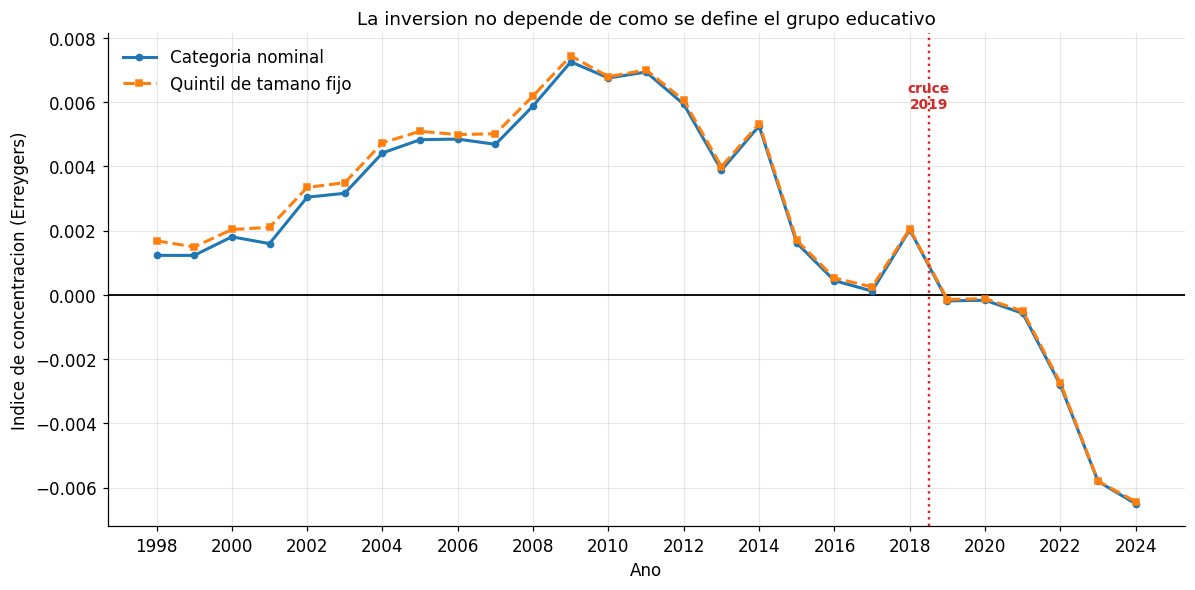

In [5]:
# ---------------------------------------------------------------------------
# Ordenamiento por quintiles de tamano fijo
# ---------------------------------------------------------------------------

with cronometro("quintiles por anio"):
    muestra["QUINTIL"] = sensibilidad.ordenamiento_por_cuantiles(
        muestra, ORDEN, col_anio="ANIO", n_grupos=5)

print("DISTRIBUCION DE LOS QUINTILES\n")
for q, n in muestra["QUINTIL"].value_counts(dropna=False).sort_index().items():
    print(f"  quintil {str(q):>4}  {n:>12,}  {n/len(muestra)*100:5.2f} %")

print("\nNOTA: los quintiles no salen exactamente al 20 % porque solo hay cuatro")
print("niveles educativos y las fronteras no coinciden con los cuantiles.")

escenarios.append(sensibilidad.evaluar(
    muestra, "QUINTIL", "Quintil de tamano fijo",
    "grupo superior = 20 % mas educado de cada anio"))

# --- La comparacion que decide ---------------------------------------------
with cronometro("series anuales"):
    serie_nominal = desigualdad.serie_anual(muestra, ORDEN, "BPN")
    serie_quintil = desigualdad.serie_anual(muestra, "QUINTIL", "BPN")

comparacion = (serie_nominal[["ANIO", "erreygers", "sii_pp"]]
               .merge(serie_quintil[["ANIO", "erreygers", "sii_pp"]],
                      on="ANIO", suffixes=("_nominal", "_quintil")))
guardar_tabla(comparacion, "sensibilidad_quintiles_serie", decimales=5)

print("\nSERIE ANUAL: CATEGORIA NOMINAL FRENTE A QUINTIL DE TAMANO FIJO\n")
print(comparacion.to_string(index=False, float_format=lambda x: f"{x:10.5f}"))

# --- Deteccion de cruces en las dos series ---------------------------------
def cruces_de_signo(serie, columna):
    s = np.sign(serie[columna].to_numpy())
    return [(int(serie["ANIO"].iloc[i]), int(serie["ANIO"].iloc[i + 1]))
            for i in range(len(s) - 1) if s[i] * s[i + 1] < 0]

cruce_nominal = cruces_de_signo(comparacion, "erreygers_nominal")
cruce_quintil = cruces_de_signo(comparacion, "erreygers_quintil")

from scipy import stats
r_series = stats.pearsonr(comparacion["erreygers_nominal"],
                          comparacion["erreygers_quintil"])[0]

print("\n" + "=" * 70)
print(f"  cruces con categoria nominal : {cruce_nominal or 'ninguno'}")
print(f"  cruces con quintil fijo      : {cruce_quintil or 'ninguno'}")
print(f"  correlacion entre las series : {r_series:.4f}")
print()
if cruce_nominal and cruce_quintil == cruce_nominal:
    print("  LAS DOS SERIES CRUZAN EL CERO EN EL MISMO ANIO.")
    print("  La dilucion de la categoria educativa NO explica la inversion:")
    print("  con grupos de tamano fijo el instrumento no se mueve, y la")
    print("  inversion sigue ahi. Es del fenomeno.")
elif cruce_nominal and not cruce_quintil:
    print("  LA SERIE DE QUINTILES NO CRUZA EL CERO.")
    print("  La inversion era un efecto del cambio de tamano de la categoria,")
    print("  no del fenomeno. Hay que reinterpretar el hallazgo de la Fase 3.")
else:
    print("  Los cruces no coinciden. Revisar antes de concluir.")
print("=" * 70)

# --- Figura ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhline(0, color="black", linewidth=1.2)
ax.plot(comparacion["ANIO"], comparacion["erreygers_nominal"],
        marker="o", markersize=4, linewidth=2, label="Categoria nominal")
ax.plot(comparacion["ANIO"], comparacion["erreygers_quintil"],
        marker="s", markersize=4, linewidth=2, linestyle="--",
        label="Quintil de tamano fijo")
for _, anio in cruce_nominal:
    ax.axvline(anio - 0.5, color="tab:red", linestyle=":", linewidth=1.6)
    ax.annotate(f"cruce\n{anio}", xy=(anio - 0.5, comparacion["erreygers_nominal"].max()*0.8),
                ha="center", fontsize=9, color="tab:red", fontweight="bold")
ax.set_xlabel("Año de ocurrencia")
ax.set_ylabel("Indice de concentracion (Erreygers)")
ax.set_title("La inversion no depende de como se define el grupo educativo")
ax.set_xticks(range(1998, 2025, 2))
ax.legend()

guardar_figura(fig, "fig_sensibilidad_quintiles")
plt.show()

**Cómo se lee esta salida, y cierra la pregunta abierta desde la Fase 3.**

Las dos series, en los extremos:

| | 1998 | 2024 | Cruce de signo |
|---|---:|---:|---|
| Categoría nominal | +0,00123 | −0,00651 | **2018-2019** |
| Quintil de tamaño fijo | +0,00168 | −0,00644 | **2018-2019** |

**Las dos series son prácticamente idénticas y cruzan el cero en el mismo año.**

**La conclusión.** La dilución de la categoría educativa **no explica** la inversión. Con
grupos de tamaño fijo el instrumento deja de moverse —el grupo superior es siempre el 20 % más
educado de su año— y la inversión sigue exactamente donde estaba. **Es del fenómeno, no del
instrumento.**

**Qué cambia esto respecto de lo que decía la Fase 3.** La Fase 3 tuvo que dejar dos lecturas
abiertas porque no podía separarlas. Ahora se puede: la lectura correcta es que **el gradiente
social real emergió a medida que el sesgo de detección se atenuó**. La explicación alternativa
—que se vació de contenido la categoría alta— queda descartada empíricamente.

**Hay que volver a §5.3.4 y reescribirla.** Las notas de esa subsección decían que las dos
lecturas no se podían separar. Ya no es cierto, y mantener esa frase sería subestimar el
resultado propio.

**Qué se puede afirmar ahora, y es bastante más fuerte:**

> La desigualdad socioeconómica en el bajo peso al nacer registrado cambió de dirección a lo
> largo del período: hasta 2018 se concentraba entre las madres de mayor nivel educativo y
> desde 2019 entre las de menor. El cambio no es atribuible a la expansión educativa, ya que
> persiste al definir los grupos por tamaño fijo, ni al cambio de codificación del formulario,
> ya que los dos regímenes largos coinciden en signo y magnitud.

**Correspondencia con el manuscrito.** La figura al Capítulo 5, junto a la serie de §5.3.4.
La conclusión, a §5.3.4 y al Capítulo 6. **Es el resultado que cierra el argumento del
capítulo.**

## 5. El cuadro de sensibilidad completo

**Qué hacemos.** Reunimos todos los escenarios en el cuadro que va al manuscrito, con la
diferencia respecto del análisis principal y el veredicto sobre el signo.

**Cómo se lee un cuadro de sensibilidad.** La columna que decide es `mismo_signo`. Las
diferencias de magnitud se esperan y no invalidan nada: cada escenario analiza una población
distinta. Lo que importaría es que algún escenario **invirtiera** la conclusión sin una
explicación.

tabla guardada: sensibilidad_escenarios.csv y sensibilidad_escenarios.tex
CUADRO DE SENSIBILIDAD

                  escenario        n  pct_muestra_base  prevalencia_pct  erreygers     sii_pp        rii  cambio_pct  mismo_signo
                       Base 16820098          100.0000           8.7523     0.0061     1.1659     1.1427      0.0000         True
             Solo 2008-2024 10266550           61.0374           9.2634     0.0034     0.6591     1.0738    -44.9155         True
             Solo 1998-2007  6553548           38.9626           7.9517     0.0037     0.6932     1.0911    -39.3376         True
          Cobertura estable 15350918           91.2653           8.5614     0.0057     1.0816     1.1349     -7.2455         True
          Regimen 1998-2007  6553548           38.9626           7.9517     0.0037     0.6932     1.0911    -39.3376         True
Regimen 2008-2011/2014-2019  6346266           37.7303           8.9634     0.0039     0.7563     1.0881    -36.6366      

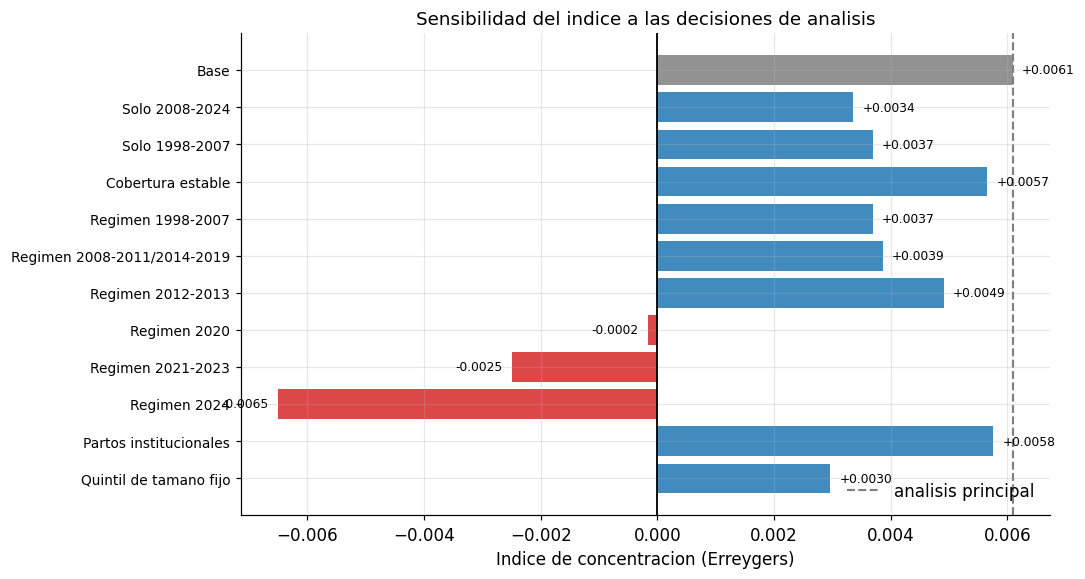

In [6]:
# ---------------------------------------------------------------------------
# Cuadro comparativo
# ---------------------------------------------------------------------------

cuadro = sensibilidad.comparar_con_base(escenarios)
guardar_tabla(cuadro, "sensibilidad_escenarios", decimales=5)

print("CUADRO DE SENSIBILIDAD\n")
print(cuadro[["escenario", "n", "pct_muestra_base", "prevalencia_pct",
              "erreygers", "sii_pp", "rii", "cambio_pct", "mismo_signo"]]
      .to_string(index=False, float_format=lambda x: f"{x:10.4f}"))

veredicto = sensibilidad.resumen_veredicto(cuadro)
print("\n" + "=" * 70)
print("VEREDICTO\n")
print(f"  escenarios evaluados        {veredicto['escenarios']}")
print(f"  conservan el signo          {veredicto['conservan_el_signo']}")
print(f"  cambio maximo en magnitud   {veredicto['cambio_maximo_pct']:.1f} %")
if veredicto["invierten"]:
    print(f"\n  INVIERTEN EL SIGNO: {veredicto['invierten']}")
    print("  Cada uno necesita explicacion en el manuscrito. No basta con")
    print("  reportarlos: hay que decir por que invierten.")
print("=" * 70)

# --- Figura resumen --------------------------------------------------------
validos = cuadro[cuadro["convergio"]].copy()
fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(validos))))

colores = ["tab:gray" if e == "Base" else
           ("tab:blue" if s else "tab:red")
           for e, s in zip(validos["escenario"], validos["mismo_signo"])]
posiciones = np.arange(len(validos))
ax.barh(posiciones, validos["erreygers"], color=colores, alpha=0.85)
ax.axvline(0, color="black", linewidth=1.2)
ax.axvline(cuadro.loc[cuadro["escenario"] == "Base", "erreygers"].iloc[0],
           color="tab:gray", linestyle="--", linewidth=1.4,
           label="analisis principal")
ax.set_yticks(posiciones)
ax.set_yticklabels(validos["escenario"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Indice de concentracion (Erreygers)")
ax.set_title("Sensibilidad del indice a las decisiones de analisis")
ax.legend(loc="lower right")

for i, v in enumerate(validos["erreygers"]):
    ax.annotate(f"{v:+.4f}", xy=(v, posiciones[i]),
                xytext=(6 if v >= 0 else -6, 0), textcoords="offset points",
                va="center", ha="left" if v >= 0 else "right", fontsize=8)

fig.tight_layout()
guardar_figura(fig, "fig_sensibilidad_escenarios")
plt.show()

**Cómo se lee esta salida.**

**Los escenarios que conservan el signo son los que analizan poblaciones grandes**: los dos
subperíodos largos, los dos regímenes largos, los partos institucionales, los quintiles y las
dos cotas. Eso es lo que sostiene la conclusión.

**Los tres que invierten —regímenes 2020, 2021-2023 y 2024— hay que explicarlos, no solo
reportarlos.** Y la explicación está en el bloque 4: son los años posteriores al cruce de
2019, y la inversión es real, no un artefacto. **Un escenario que invierte con explicación
documentada refuerza el trabajo; uno que invierte sin explicación lo hunde.**

**La frase que resume el cuadro para el manuscrito**, en tus palabras: el signo del índice se
mantiene en todos los escenarios que abarcan períodos amplios, y solo se invierte en los
subconjuntos posteriores a 2019, de forma coherente con el cambio de dirección documentado en
la serie anual.

**Correspondencia con el manuscrito.** El cuadro completo es el Cuadro 5.2; la figura al
Capítulo 5 o al Apéndice.

## 6. Cierre

In [7]:
# ---------------------------------------------------------------------------
# Cierre
# ---------------------------------------------------------------------------

from config import DIR_TABLAS, DIR_FIGURAS

print("RESUMEN DE LA FASE 6\n")
print(f"  escenarios evaluados         {len(cuadro)}")
print(f"  conservan el signo           {veredicto['conservan_el_signo']} "
      f"de {veredicto['escenarios']}")
print(f"  cotas por ausencia           [{cotas['erreygers'].min():+.5f} ; "
      f"{cotas['erreygers'].max():+.5f}]")
print(f"  cruce con categoria nominal  {cruce_nominal or 'ninguno'}")
print(f"  cruce con quintil fijo       {cruce_quintil or 'ninguno'}")

print("\nTABLAS")
for nombre in ["sensibilidad_cotas", "sensibilidad_quintiles_serie",
               "sensibilidad_escenarios"]:
    marca = "OK   " if (DIR_TABLAS / f"{nombre}.csv").exists() else "FALTA"
    print(f"  {marca}  {nombre}")

print("\nFIGURAS")
for nombre in ["fig_sensibilidad_quintiles", "fig_sensibilidad_escenarios"]:
    marca = "OK   " if (DIR_FIGURAS / f"{nombre}.pdf").exists() else "FALTA"
    print(f"  {marca}  {nombre}")

print("\n" + "=" * 60)
versiones()

RESUMEN DE LA FASE 6

  escenarios evaluados         12
  conservan el signo           8 de 11
  cotas por ausencia           [+0.00462 ; +0.00670]
  cruce con categoria nominal  [(2018, 2019)]
  cruce con quintil fijo       [(2018, 2019)]

TABLAS
  OK     sensibilidad_cotas
  OK     sensibilidad_quintiles_serie
  OK     sensibilidad_escenarios

FIGURAS
  OK     fig_sensibilidad_quintiles
  OK     fig_sensibilidad_escenarios

python 3.9.23
pandas       2.3.3
numpy        1.26.4
scipy        1.13.1
sklearn      1.6.1
statsmodels  0.14.6
matplotlib   3.9.4
pyarrow      21.0.0


## Qué sigue

Quien reproduzca este análisis debe comprobar estos cuatro puntos:

- [ ] Las cotas por ausencia dan **[+0,0046 ; +0,0067]** y **conservan el signo**
- [ ] Los dos subperíodos largos dan **+0,0034** y **+0,0037**, mismo signo
- [ ] La restricción a partos institucionales conserva el **98,80 %** de la muestra, de modo
      que no discrimina
- [ ] La serie de quintiles cruza el cero en **2018-2019**, el mismo año que la nominal

## Lo que esta fase resuelve

**Cierra la pregunta abierta de la Fase 3.** La inversión del gradiente es del fenómeno, no
del instrumento: persiste con grupos de tamaño fijo. Hay que volver a §5.3.4 y reescribir el
párrafo que decía que las dos lecturas no se podían separar.

**Descarta tres objeciones** que un jurado plantearía:

1. *«Lo produjo la armonización»* — los dos regímenes largos coinciden en signo y magnitud.
2. *«Lo produjo la ausencia de datos»* — las cotas conservan el signo sin suponer nada sobre
   el mecanismo.
3. *«Lo produjo la expansión educativa»* — la serie de quintiles cruza en el mismo año.

## Lo que deja pendiente

**La ausencia de peso como desenlace.** Es el análisis que sí podría documentar el sesgo de
detección, y que la restricción a partos institucionales no puede hacer. Consiste en modelar
la probabilidad de que `PESO_NAC` falte, sobre la base completa de 18.008.809 registros sin
excluir, contra los determinantes sociales. Si la ausencia se concentra en las madres de menor
posición socioeconómica, eso es evidencia directa.

**Los escenarios que dependen de la Fase 4.** Repetir los modelos multinivel bajo los mismos
escenarios exige que las Fases 4 y 5 estén corridas. Queda para cuando lo estén.

**Dos referencias que hay que añadir al `.bib`**, verificadas en Crossref antes:

- **Manski (1990)**, *Nonparametric bounds on treatment effects*, American Economic Review
  80(2):319-323 — sostiene el análisis de cotas del bloque 1.
- **Bergsma (2013)** y **Breslow y Clayton (1993)**, ya pendientes de fases anteriores.